In [1]:

from gensim import corpora
import gensim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import CoherenceModel
from tqdm import tqdm
import torch
import torch.nn.functional as F
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
from transformers import AutoTokenizer, AutoModel
# 加载预训练的中文Word2Vec模型（例如，腾讯的中文词向量）
word_vectors = gensim.models.KeyedVectors.load_word2vec_format('tencent-ailab-embedding-zh-d100-v0.2.0-s/tencent-ailab-embedding-zh-d100-v0.2.0-s.txt', binary=False)
print('加载模型腾讯word2vec成功')

加载模型腾讯word2vec成功


In [2]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

# 下载源：https://huggingface.co/google-bert/bert-base-chinese
bert_tokenizer = AutoTokenizer.from_pretrained("sentence_transformer/")
bert_model = AutoModelForMaskedLM.from_pretrained("sentence_transformer/")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
state_dict = torch.load('sentence_transformer/mlm_chkpt.pth',map_location='cpu')
bert_model.load_state_dict(state_dict)
bert_model.eval()
bert_model = bert_model.to(device)

HFValidationError: Repo id must use alphanumeric chars or '-', '_', '.', '--' and '..' are forbidden, '-' and '.' cannot start or end the name, max length is 96: 'sentence_transformer/'.

In [3]:
# Mean Pooling - Take attention mask into account for correct averaging
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0] #First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

# 创建文档向量
@torch.no_grad()
def document2vector(doc,name2idx):
    return_vector = np.zeros(len(name2idx))

    # Tokenize sentences
    encoded_input = bert_tokenizer(doc, padding=True, truncation=True, return_tensors='pt')
    encoded_input =  {k:v.to(device) for k,v in encoded_input.items()}
    # Compute token embeddings
    with torch.no_grad():
        model_output = bert_model(**encoded_input)
        # Perform pooling. In this case, max pooling.
        sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
    words = doc.split(' ')
    words = [word for word in words if word in name2idx.keys() and len(word)>1]
    if len(words) <= 0 :
        return return_vector
    
    # Tokenize sentences
    encoded_input = bert_tokenizer(words, padding=True, truncation=True, return_tensors='pt')
    encoded_input =  {k:v.to(device) for k,v in encoded_input.items()}
    # Compute token embeddings
    with torch.no_grad():
        model_output = bert_model(**encoded_input)
        # Perform pooling. In this case, max pooling.
        words_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
        # 计算余弦相似度
        cosine_similarities = F.cosine_similarity(words_embeddings, sentence_embeddings, dim=1)
    sims = cosine_similarities.detach().cpu().numpy()
    for word , sim in zip(words,sims):
        return_vector[name2idx[word]] = abs(sim)
    return return_vector

# ‌文档向量构建（document2vector函数）‌
#‌输入‌：单篇文档 doc 和词汇表到索引的映射 name2idx。
#‌输出‌：一个与词汇表等长的向量，每个位置的值表示对应词与文档整体的语义相关性（通过余弦相似度计算）。

def tokenize(text):
    return text.split(' ')

topic_num = 5
num_words_per_topic = 10 # 每个主题内的关键词数量
with open(f'data/clean_sentence_v2.txt','r') as file:
    documents = [line.strip().split(',')[1] for line in file.readlines()]

# 构建词表
vectorizer = TfidfVectorizer(tokenizer=tokenize,max_features=5000)#tokenizer=tokenize指定自定义的分词函数 tokenize，用于将文本拆分为词项（Token）。
# max_features=5000限制词汇表大小为 5000 个词项，仅保留 TF-IDF 权重最高的前 5000 个特征词
X = vectorizer.fit_transform(documents) # 生成TF-IDF矩阵
feature_names = vectorizer.get_feature_names_out() # 获取特征词列表
feature2idx = {feature:idx for idx,feature in enumerate(feature_names)} # 构建词到索引的映射

In [4]:
# 对文档进行编码
doc_embeddings = []
for doc in tqdm(documents):
    doc_embed = document2vector(doc,feature2idx)
    doc_embeddings.append(doc_embed)

print(f'完成编码')

# 这段代码的作用是 ‌将文本集合中的每个文档转换为结构化向量表示‌，最终生成一个文档-词权重矩阵，用于后续的机器学习任务（如LDA主题建模）。以下是具体分析：

#1. 核心目标：文档向量化‌
#输入‌：原始文本集合 documents（如 ["自然语言处理很有趣", "深度学习需要大量数据"]）。
#输出‌：矩阵 doc_embeddings，形状为 [n_docs, vocab_size]，其中：
#每行对应一个文档的向量表示。
#每列对应词汇表中的一个词。
#元素值表示 ‌词与文档的语义相关性权重‌（通过BERT计算的余弦相似度）。

100%|██████████| 12317/12317 [06:54<00:00, 29.72it/s]

完成编码


In [14]:
lda = LatentDirichletAllocation(n_components=topic_num, random_state=42)
W = lda.fit_transform(doc_embeddings)
H = lda.components_

# 打印每个主题的关键词
def print_top_words(model, feature_names, num_words_per_topic):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-num_words_per_topic - 1:-1]]))

print_top_words(lda, feature_names, num_words_per_topic)

Topic 1:
舒服 舒适 合适 起来 柔软 大小 设计 好看 颜色 方便
Topic 2:
购物 发货 收到 一次 服务态度 卖家 商品 快递 客服 宝贝
Topic 3:
外观 效果 游戏 性能 使用 性价比 问题 电脑 保护 运行
Topic 4:
味道 口感 方便 好吃 回购 性价比 比较 实惠 起来 口味
Topic 5:
一直 下次 实惠 好评 便宜 特别 放心 划算 开心 还会


In [15]:
# 创建字典
id2word = corpora.Dictionary([tokenize(doc) for doc in documents])

# 转换为gensim的corpus格式
gensim_corpus = [id2word.doc2bow(tokenize(doc)) for doc in documents]

# 获取每个主题的前n个词
def get_topic_words(model, feature_names, n_top_words):
    topic_words_probs = []
    for topic in model.components_:
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        probs = [topic[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        prob_sum = sum(probs)
        topic_words_probs.append([(word ,prob/prob_sum) for word ,prob in zip(top_words,probs)])

    return topic_words_probs

topic_words_probs = get_topic_words(lda, feature_names, num_words_per_topic)


# 计算主题一致性指标
topic_words = []
for item_list in topic_words_probs:
    topic_words.append([item[0] for item in item_list])


    
coherence_model_cv = CoherenceModel(topics=topic_words, texts=[tokenize(doc) for doc in documents], dictionary=id2word, coherence='c_v')

coherence_model_cpmi = CoherenceModel(topics=topic_words, texts=[tokenize(doc) for doc in documents], dictionary=id2word, coherence='c_npmi')

coherence_model_uci = CoherenceModel(topics=topic_words, texts=[tokenize(doc) for doc in documents], dictionary=id2word, coherence='c_uci')

coherence_model_umass = CoherenceModel(topics=topic_words, texts=[tokenize(doc) for doc in documents],corpus=gensim_corpus, dictionary=id2word, coherence='u_mass')
# assert False
# 打印结果
print(f"C_v coherence: {coherence_model_cv.get_coherence()}")
print(f"C_pmi coherence: {coherence_model_cpmi.get_coherence()}")
print(f"C_uci coherence: {coherence_model_uci.get_coherence()}")
print(f"U_mass coherence: {coherence_model_umass.get_coherence()}")

C_v coherence: 0.6956964787188067
C_pmi coherence: 0.10474126367716763
C_uci coherence: 0.5726596243623976
U_mass coherence: -2.0090907527445183


In [16]:
'''主题间的差异性——Jaccard相似度,越低越好'''

# 计算主题词之间的重叠度，重叠度越低，表示主题之间的差异性越大

def jaccard_similarity(list1, list2):
    s1 = set(list1)
    s2 = set(list2)
    return len(s1.intersection(s2)) / len(s1.union(s2))

# 假设lda_model是训练好的LDA模型
jaccard_scores = []
for i in range(len(topic_words_probs)):
    for j in range(i + 1, len(topic_words_probs)):
        words_i = [word for word, prob in topic_words_probs[i]]
        words_j = [word for word, prob in topic_words_probs[j]]
        jaccard_scores.append(jaccard_similarity(words_i, words_j))

avg_jaccard_score = sum(jaccard_scores) / len(jaccard_scores)
print(f'Average Jaccard similarity: {avg_jaccard_score}')

# 计算主题分布之间的KL散度来衡量它们的差异性。KL散度越大，表示主题之间的差异性越大。
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
# 假设word_vectors是预训练的词向量模型
def get_topic_vector(topic, word_vectors):
    vector = np.zeros(word_vectors.vector_size)
    for word, prob in topic:
        if word in word_vectors:
            vector += prob * word_vectors[word]
    return vector

# 获取每个主题的向量表示
topic_vectors = []
for topic in topic_words_probs:
    topic_vector = get_topic_vector(topic, word_vectors)
    topic_vectors.append(topic_vector)

# 计算余弦相似度
cosine_similarities = cosine_similarity(topic_vectors)
avg_cosine_similarity = np.mean(cosine_similarities[np.triu_indices(len(topic_vectors), k=1)])
print(f'Average cosine similarity: {avg_cosine_similarity}') # 越低越好，接近0最好


Average Jaccard similarity: 0.021637426900584796
Average cosine similarity: 0.6967661977014739


num of topic :  5 5


/home/find-yupei/.local/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/home/find-yupei/.local/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/tmp/ipykernel_1549228/4127221656.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color = plt.cm.get_cmap('tab10')(label / topic_num)  # 使用不同颜色代表不同主题
/tmp/ipykernel_1549228/4127221656.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color = plt.cm.get_cmap('ta

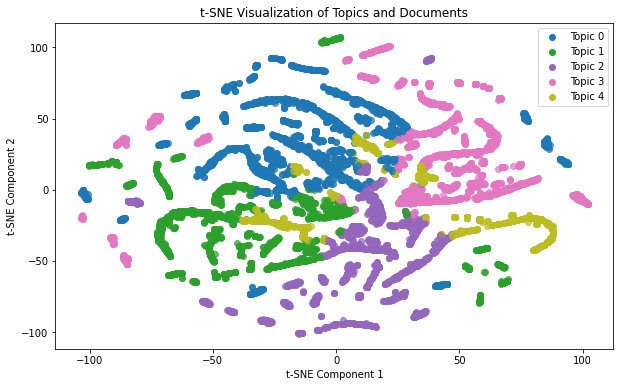

In [17]:
import gensim
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 定义函数获取主题向量
def get_topic_vector(topic, word_vectors):
    vector = np.zeros(word_vectors.vector_size)
    word_count = 0
    for word, prob in topic:
        if word in word_vectors:
            vector += prob * word_vectors[word]
            word_count += 1
    if word_count > 0:
        vector /= word_count
    return vector

# 获取每个主题的向量表示
topic_vectors = []
for topic in topic_words_probs:
    topic_vector = get_topic_vector(topic, word_vectors)
    topic_vectors.append(topic_vector)

print('num of topic : ',len(topic_vectors),topic_num)

# 获取每个文档所属的主题
document_vectors = []
document_labels = []  # 存储文档所属主题
for doc_id, tpoics_prob in enumerate(W):
    tpoics_prob = tpoics_prob / sum(tpoics_prob)
    doc_vector = np.zeros(word_vectors.vector_size)
    topic_index = tpoics_prob.argsort()[::-1]
    max_topic = topic_index[0]
    document_labels.append(max_topic)  # 记录文档所属的主题
    for t_num, prob in enumerate(tpoics_prob):
        doc_vector += prob * topic_vectors[t_num]
    document_vectors.append(doc_vector)

# 将主题向量和文档向量组合在一起
all_vectors = np.vstack((topic_vectors, document_vectors))
# 使用t-SNE降维
tsne_model = TSNE(n_components=2, random_state=1)
tsne_vectors = tsne_model.fit_transform(all_vectors)
# 分离t-SNE降维结果中的主题和文档向量
tsne_topic_vectors = tsne_vectors[:len(topic_vectors)]
tsne_document_vectors = tsne_vectors[len(topic_vectors):]
# 可视化
plt.figure(figsize=(10, 6))
# 绘制文档
for i, label in enumerate(document_labels):
    color = plt.cm.get_cmap('tab10')(label / topic_num)  # 使用不同颜色代表不同主题
    plt.scatter(tsne_document_vectors[i, 0], tsne_document_vectors[i, 1], color=color, alpha=0.7)
# 绘制主题
for i, label in enumerate(range(topic_num)):
    color = plt.cm.get_cmap('tab10')(label / topic_num)  # 使用不同颜色代表不同主题
    plt.scatter(tsne_topic_vectors[i, 0], tsne_topic_vectors[i, 1], color=color, label=f'Topic {label}')
    # plt.annotate(f'Topic {label}', (tsne_topic_vectors[i, 0], tsne_topic_vectors[i, 1]), textcoords="offset points", xytext=(0, 10), ha='center', color='black')
plt.title("t-SNE Visualization of Topics and Documents")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()

In [ ]:
import gensim
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 定义函数获取主题向量
def get_doc_vecotr(sents, word_vectors):
    vector = np.zeros(word_vectors.vector_size)
    word_count = 0
    for word in sents:
        if word in word_vectors:
            vector +=  word_vectors[word]
            word_count += 1
    if word_count > 0:
        vector /= word_count
    return vector

# 获取每个文档所属的主题
document_labels = []  # 存储文档所属主题
for doc_id, tpoics_prob in enumerate(W):
    topic_index = tpoics_prob.argsort()[::-1]
    max_topic = topic_index[0]
    document_labels.append(max_topic)  # 记录文档所属的主题
   
document_vectors = []
for doc_id , sent in enumerate(documents):
    doc_vector = get_doc_vecotr(sent.split(' '),word_vectors)
    document_vectors.append(doc_vector)
# 将主题向量和文档向量组合在一起
all_vectors = np.array(document_vectors)
# 使用t-SNE降维
tsne_model = TSNE(n_components=2, random_state=1)
tsne_vectors = tsne_model.fit_transform(all_vectors)
# 可视化
plt.figure(figsize=(10, 6))
# 绘制文档
for i, label in enumerate(document_labels):
    color = plt.cm.get_cmap('tab10')(label / topic_num)  # 使用不同颜色代表不同主题
    plt.scatter(tsne_vectors[i, 0], tsne_vectors[i, 1], color=color, alpha=0.7)
plt.title("t-SNE Visualization of Topics and Documents")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()

In [ ]:
# 计算组内的文本相似度
documents_dict = {}

# 定义函数获取主题向量
def get_doc_vecotr(sents, word_vectors):
    vector = np.zeros(word_vectors.vector_size)
    word_count = 0
    for word in sents:
        if word in word_vectors:
            vector +=  word_vectors[word]
            word_count += 1
    if word_count > 0:
        vector /= word_count
    return vector

for doc_idx , (doc_label ,doc_sent) in enumerate(zip(document_labels,documents)):
    tmp = documents_dict.get(doc_label,[])
    doc_vec = get_doc_vecotr(doc_sent.split(' '),word_vectors)
    tmp.append(doc_vec)
    documents_dict[doc_label] = tmp

doc_vecotors = []
for label , item in documents_dict.items():
    all_vec= np.array(item)
    doc_vecotors.append(np.mean(all_vec,axis=0))

cosine_similarities = cosine_similarity(doc_vecotors)
avg_cosine_similarity = np.mean(cosine_similarities[np.triu_indices(len(doc_vecotors), k=1)])
print(f'Doc across different topics : {avg_cosine_similarity}') # 越低越好，接近0最好


cos_list = []
for label , item in documents_dict.items():
    item = [np.array(i) for i in item]
    cosine_similarities = cosine_similarity(item)
    avg_cosine_similarity = np.mean(cosine_similarities[np.triu_indices(len(item), k=1)])
    cos_list.append(avg_cosine_similarity)
print(f'Doc in single topic : {sum(cos_list)/len(cos_list)}') # 越高越好